In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import sys

sys.path.append('../')
from carpet_reconstruction import GetCarpetSignal, num_sort

In [2]:
plt.rcParams['figure.dpi'] = 200

In [4]:
path = 'Data/iron_roof/'

filenames = [path + filename for filename in os.listdir(path)]
filenames.sort(key=num_sort)

In [5]:
h = 10

all_parameters = np.empty((0, 7))
all_signals = np.empty((0, 400))
all_times = np.empty((0, 4))
all_muon_summs = np.empty((0, 1))

for ind, filename in enumerate(filenames):

    starting_shower = ind*1000

    print(filename)

    file = uproot.open(filename)
    
    names = np.array(file.keys())
    times = names[:len(names) // 3]
    cover_hists = names[len(names) // 3::2]
    muon_hists = names[len(names) // 3 + 1::2]
    
    cover_signals = np.zeros((len(cover_hists), 400))
    parameters = np.zeros((len(cover_hists), 7))
    muon_summ = np.zeros(len(muon_hists))
    time_array = np.zeros((len(times), 4))
    
    for i, hist in enumerate(cover_hists):
        
        cov_hist = np.copy(np.flip(file[hist].values().T, 0))
        cover_signals[i] = GetCarpetSignal(cov_hist).flatten()
    
        params = np.array(hist.split(';')[0].split('_')).astype(float)
        params[3] += h*np.tan(np.radians(params[1]))*np.sin(np.radians(params[2]))
        params[4] += h*np.tan(np.radians(params[1]))*np.cos(np.radians(params[2]))
        params[2] = 90 - params[2]
        if params[2] > 180:
            params[2] -= 360
        
        parameters[i] = params

    for i, muon_hist in enumerate(muon_hists):
        muon_summ[i] = file[muon_hist].values().sum()
    
    for i, t in enumerate(times):
        time_array[i] = file[t]['t_ns'].array(library='np')[1:5]

    all_parameters = np.vstack((all_parameters, parameters))
    all_signals = np.vstack((all_signals, cover_signals))
    all_muon_summs = np.vstack((all_muon_summs, muon_summ[:, np.newaxis]))
    all_times = np.vstack((all_times, time_array))

Data/iron_roof/output0.root
Data/iron_roof/output1.root
Data/iron_roof/output2.root
Data/iron_roof/output3.root
Data/iron_roof/output4.root
Data/iron_roof/output5.root
Data/iron_roof/output6.root
Data/iron_roof/output7.root
Data/iron_roof/output8.root
Data/iron_roof/output9.root
Data/iron_roof/output10.root
Data/iron_roof/output11.root
Data/iron_roof/output12.root
Data/iron_roof/output13.root
Data/iron_roof/output14.root
Data/iron_roof/output15.root
Data/iron_roof/output16.root
Data/iron_roof/output17.root
Data/iron_roof/output18.root
Data/iron_roof/output19.root
Data/iron_roof/output20.root
Data/iron_roof/output21.root
Data/iron_roof/output22.root
Data/iron_roof/output23.root
Data/iron_roof/output24.root
Data/iron_roof/output25.root
Data/iron_roof/output26.root
Data/iron_roof/output27.root
Data/iron_roof/output28.root


In [6]:
all_data = pd.concat([pd.DataFrame(all_parameters, columns=['E, TeV', 'Theta, deg', 'Phi, deg', 'x, m', 'y, m', 'Z_first, cm', 'Ne']), pd.DataFrame(all_muon_summs, columns=['N_mu total']), pd.DataFrame(all_times, columns=['remote one trigger time, ns', 'remote two trigger time, ns', 'remote three trigger time, ns', 'remote four trigger time, ns']), pd.DataFrame(all_signals)], axis=1)

In [7]:
all_data

,"E, TeV","Theta, deg","Phi, deg","x, m","y, m","Z_first, cm",Ne,N_mu total,"remote one trigger time, ns","remote two trigger time, ns",...,390,391,392,393,394,395,396,397,398,399
0,10.0,27.95500,152.0754,-2.203769,-2.203772,3410030.0,1549.0,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,10.0,31.43950,68.7064,7.916238,7.916236,3040630.0,1758.0,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,10.0,7.00188,-5.8537,1.096514,1.096510,2961460.0,2554.0,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,10.0,10.81830,-80.4450,-1.567199,-1.567201,3220370.0,2648.0,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10.0,31.99490,-120.4430,-8.551607,-8.551612,3268930.0,1169.0,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28195,150.0,25.25350,-68.3710,-2.646247,-2.646245,4713460.0,49474.0,3.913043,167695.265625,167662.03125,...,0.546547,0.091592,0.001502,0.001502,0.630631,3.391892,0.006006,0.022523,0.019520,2.058559
28196,150.0,39.11590,40.7077,11.467262,11.467264,4488100.0,19828.0,4.576659,185703.875000,0.00000,...,0.000000,0.000000,0.028529,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
28197,150.0,24.88950,-26.1680,2.117990,2.117987,4062460.0,55147.0,11.737223,143214.046875,143179.15625,...,0.022523,0.617117,0.000000,0.418919,0.016517,0.225225,0.024024,0.000000,0.010511,0.250751
28198,150.0,22.47820,-134.7710,-5.851514,-5.851511,5095180.0,68526.0,3.892067,177850.765625,177908.90625,...,4.294294,0.524024,0.066066,0.060060,0.097598,1.503003,21.250751,0.605105,0.049550,0.704204


In [8]:
all_data.to_csv('iron_28k_roof.csv', index=False)

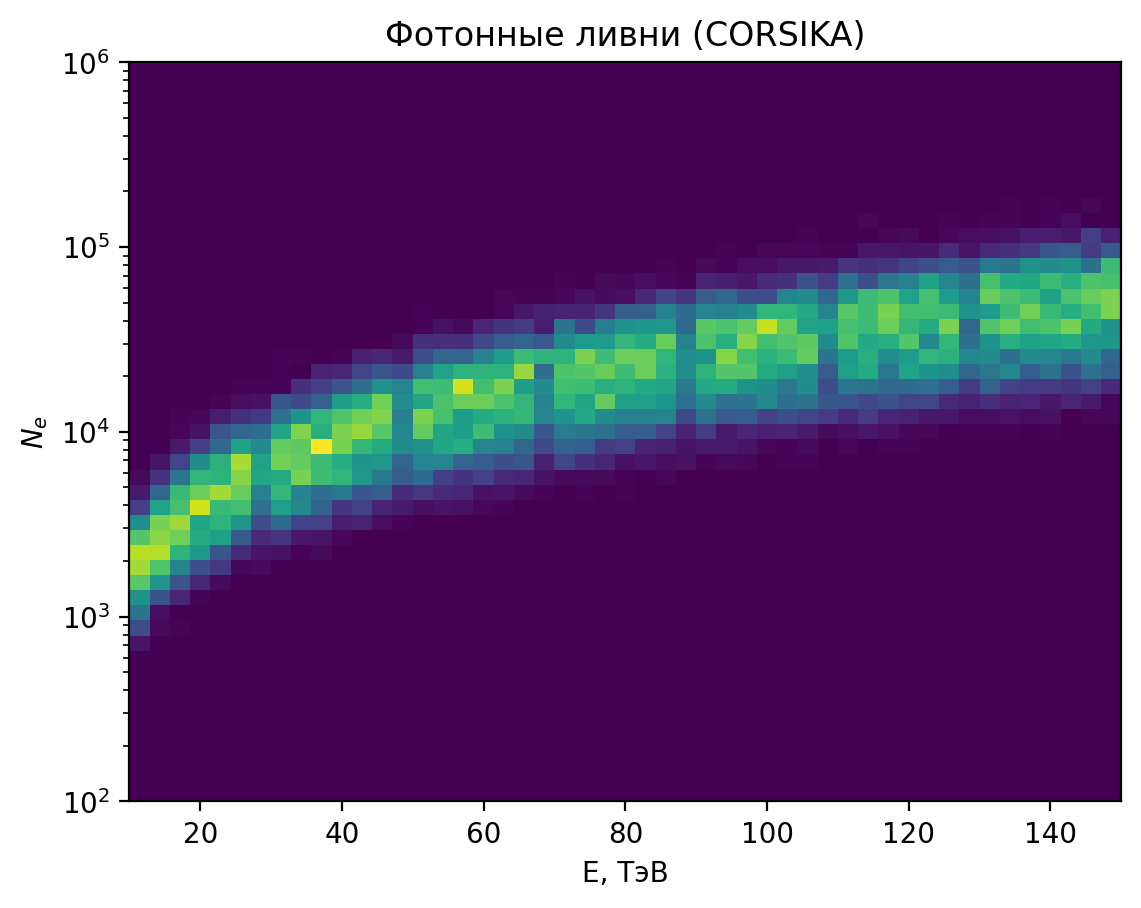

In [12]:
xbins = np.linspace(10, 150, 50)
ybins = 10**np.linspace(2, 6, 50)

plt.hist2d(all_data['E, TeV'], all_data['Ne'], bins=(xbins, ybins))

plt.yscale('log')

plt.xlabel('E, ТэВ')
plt.ylabel('$N_e$')

plt.title('Фотонные ливни (CORSIKA)')

plt.savefig('CorsikaNe.png')